# Wavefield · Elastic TTI, displacement form (Oh et al. 2020)

`ElasticTTI2nd` implements the second-order **displacement** P–SV TTI system of
Oh, Shin, Alkhalifah & Min (2020, *GJI* **223**, "Multistage elastic full
waveform inversion for tilted transverse isotropic media"). Two things set it
apart from the velocity–stress solvers `ElasticTTI` / `ElasticTTISG`:

- **Fields.** Two displacements `ux, uz` on a triple time buffer, instead of
  three velocities and five stresses.
- **Parametrisation.** The inversion variables are the *hierarchical* set
  the paper argues is better conditioned for multistage FWI:

$$v_h = v_{p0}\sqrt{1+2\varepsilon},\qquad
  \eta = \frac{\varepsilon-\delta}{1+2\delta}$$

  so the leading parameter is the **horizontal** P velocity — the one surface
  data actually constrains first — and the anellipticity η carries what is
  left. `vp0` and `δ` never appear; they are recovered from `(v_h, \eta)`.

The physics is unchanged, so a snapshot from this solver and one from
`ElasticTTISG` on the *same medium* must put the wavefront in the same place.
The last section checks exactly that.


## 1. Parameters

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import ElasticTTI2nd, ElasticTTISG
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (400, 400)             # 3.2 km x 3.2 km at 8 m spacing
dh    = 8.0
dt    = 1.0e-3
nt    = 520                    # 0.52 s
abcn  = 40
spatial_order = 4
freq, delay = 10.0, 0.10
# Keep the last snapshot inside the box: the fastest front is the horizontal
# qP at vp0*sqrt(1+2*eps) = 3036 m/s, which covers the 1600 m half-width in
# 0.53 s.
snapshot_times = (150, 320, 490)

vp0_val, vs_val, rho_val = 2400.0, 1200.0, 2200.0
epsilon_val, delta_val = 0.30, 0.05

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

ppw = vs_val / (2.5 * freq) / dh
cfl = vp0_val * np.sqrt(1 + 2 * epsilon_val) * dt / dh
print(f'S-wave ppw at fmax = {ppw:.2f}   CFL (horizontal qP) = {cfl:.3f}')
assert ppw >= 5.0 and cfl <= 0.45

device: cuda
S-wave ppw at fmax = 6.00   CFL (horizontal qP) = 0.379


## 2. The hierarchical parametrisation

Thomsen `(vp0, ε, δ)` in, Oh-2020 `(vh, η)` out — and back again. Note that
`η = 0` is the *elliptical* case (ε = δ), where the qP wavefront is an exact
ellipse; η measures the departure from it.

In [3]:
vh_val  = vp0_val * np.sqrt(1.0 + 2.0 * epsilon_val)
eta_val = (epsilon_val - delta_val) / (1.0 + 2.0 * delta_val)
print(f'vp0 = {vp0_val:7.1f} m/s   epsilon = {epsilon_val:.3f}   delta = {delta_val:.3f}')
print(f'vh  = {vh_val:7.1f} m/s   eta     = {eta_val:.3f}')

# inverse map, for the record
vp0_back   = vh_val / np.sqrt(1.0 + 2.0 * epsilon_val)
delta_back = (epsilon_val - eta_val) / (1.0 + 2.0 * eta_val)
print(f'round trip -> vp0 {vp0_back:7.1f}   delta {delta_back:.3f}')

vp0 =  2400.0 m/s   epsilon = 0.300   delta = 0.050
vh  =  3035.8 m/s   eta     = 0.227
round trip -> vp0  2400.0   delta 0.050


## 3. Uniform anisotropic model and solver

`ElasticTTI2nd` takes **six** fields: `vh, vs, rho, ε, η, θ`. There is no φ —
the P–SV system lives in the x–z plane, so a single tilt angle describes the
symmetry axis completely.

In [4]:
def build_models(theta_deg):
    full = lambda v: torch.full(shape, float(v), dtype=torch.float32, device=device)
    return [full(vh_val), full(vs_val), full(rho_val),
            full(epsilon_val), full(eta_val), full(np.deg2rad(theta_deg))]

eq = ElasticTTI2nd(spatial_order=spatial_order, device=device)
print('models :', eq.models)
print('sources:', [s.name for s in eq.available_source_fields()])
print('recs   :', [s.name for s in eq.available_receiver_fields()])

solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, dev=device, nt=nt, abcn=abcn,
                   source_type=['uz'], receiver_type=['ux', 'uz'],
                   impl='eager', use_ckpt=False)

cz, cx = shape[0] // 2, shape[1] // 2
sources   = np.array([[[cx, cz]]], dtype=np.int64)
receivers = np.array([[[cx, cz]]], dtype=np.int64)
t = np.arange(nt, dtype=np.float32) * dt - delay
wavelet = (1e3 * ricker(t, f=freq)).astype(np.float32)

models : ['vh', 'vs', 'rho', 'epsilon', 'eta', 'theta']
sources: ['ux', 'uz']
recs   : ['ux', 'uz']


## 4. Forward modeling for three tilts

In [5]:
TILTS = [('theta 0', 0.0), ('theta 30', 30.0), ('theta 60', 60.0)]
uz_idx = eq.wavefields.index('uz')
# Ask for each display time AND the step before it: the solver state is a
# DISPLACEMENT, whose near-source static offset would dominate a snapshot.
# Differencing in time gives the particle velocity, which is what the
# velocity-stress notebooks plot and what makes the wavefront legible.
pairs = sorted({t for ts in snapshot_times for t in (ts - 1, ts)})
panels = {}

for label, theta_deg in TILTS:
    with torch.no_grad():
        _, snaps = solver(wavelet, sources, receivers, models=build_models(theta_deg),
                          return_wavefield=True, snapshot_times=pairs)
    grab = lambda t: snaps[pairs.index(t), uz_idx, 0, 0,
                           abcn:abcn + shape[0], abcn:abcn + shape[1]].cpu().numpy()
    panels[label] = [(grab(ts) - grab(ts - 1)) / dt for ts in snapshot_times]
    del snaps
    print(f'  {label}: max|d(uz)/dt| at last snapshot = {np.abs(panels[label][-1]).max():.3e}')

  theta 0: max|d(uz)/dt| at last snapshot = 1.098e+05


  theta 30: max|d(uz)/dt| at last snapshot = 1.651e+05


  theta 60: max|d(uz)/dt| at last snapshot = 1.423e+05


## 5. uz snapshots

Rows are tilts, columns are times, one colour scale throughout. The qP
wavefront is the outer, near-elliptical front; its long axis rotates with θ.
The inner, slower qSV front is the one with the cusps — anellipticity η is
what puts them there.

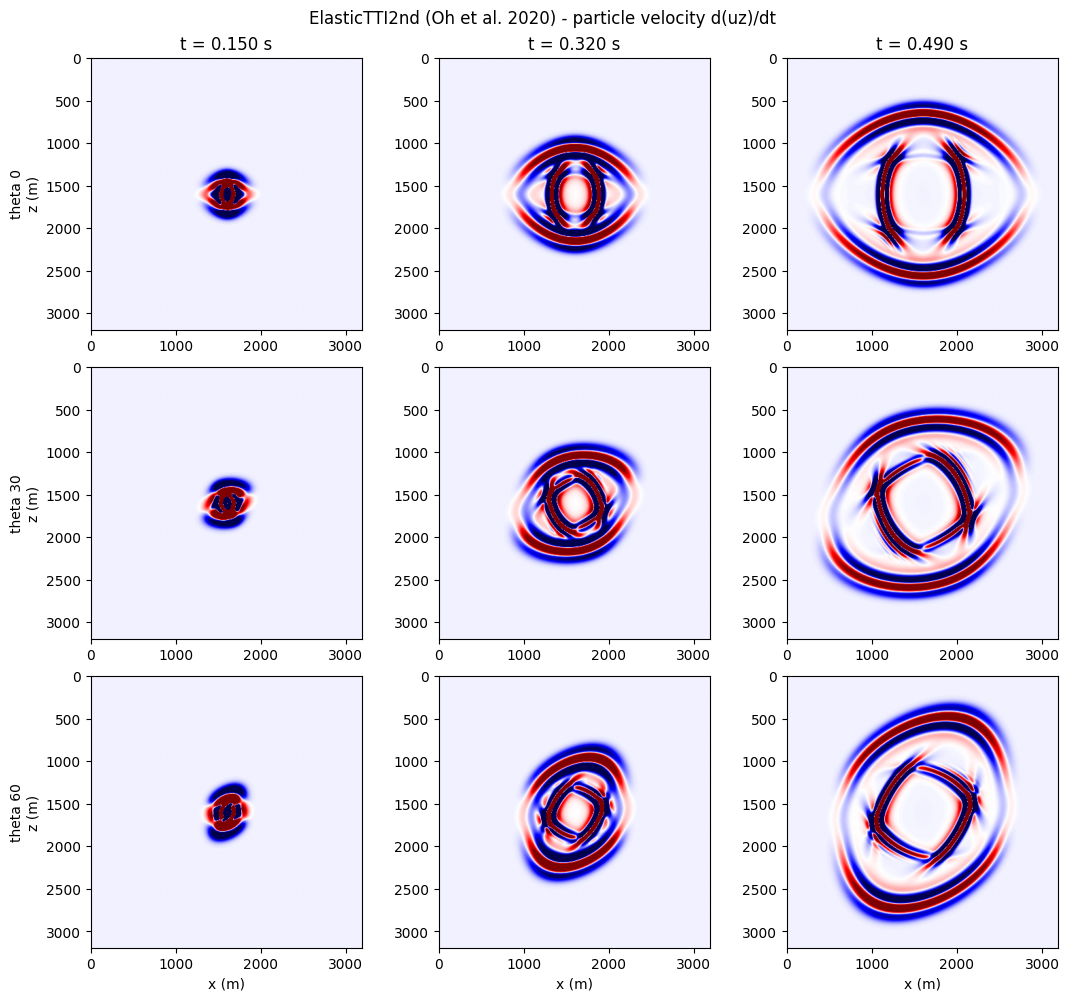

In [6]:
def lim(arrs):
    a = np.concatenate([x.ravel() for x in arrs])
    lo, hi = np.percentile(a, [2, 98])
    return float(lo), float(hi)

lo, hi = lim([p for ps in panels.values() for p in ps])
extent = (0, (shape[1] - 1) * dh, (shape[0] - 1) * dh, 0)
fig, axes = plt.subplots(len(TILTS), len(snapshot_times),
                         figsize=(3.6 * len(snapshot_times), 3.3 * len(TILTS)),
                         constrained_layout=True)
for r, (label, _) in enumerate(TILTS):
    for c, (panel, ts) in enumerate(zip(panels[label], snapshot_times)):
        ax = axes[r, c]
        ax.imshow(panel, cmap='seismic', vmin=lo, vmax=hi, aspect='equal', extent=extent)
        if r == 0:
            ax.set_title(f't = {ts * dt:.3f} s')
        if c == 0:
            ax.set_ylabel(f'{label}\nz (m)')
        if r == len(TILTS) - 1:
            ax.set_xlabel('x (m)')
fig.suptitle('ElasticTTI2nd (Oh et al. 2020) - particle velocity d(uz)/dt')
plt.show()

## 6. Cross-check against the velocity–stress solver

Same medium, same tilt, two independent formulations: `ElasticTTI2nd`
(displacement, 2nd order in time, `vh/η`) and `ElasticTTISG` (velocity–stress,
staggered grid, `vp0/ε/δ`). Kinematics do not care which one you write down,
so the **qP wavefront must sit at the same radius**.

To compare like with like, the displacement solver's state is differenced in
time — `d(uz)/dt` *is* the particle velocity, so it is directly comparable to
the staggered-grid `vz`. (Comparing raw `uz` against `vz` would put the peaks
a fraction of a wavelength apart purely because of the derivative.) The source
terms still differ between the two systems, so amplitudes are not comparable;
the wavefront *position* is.

In [7]:
theta_deg = 30.0
T = snapshot_times[-1]

sg = ElasticTTISG(spatial_order=spatial_order, device=device)
sg_solver = PropTorch(sg, shape=shape, dh=dh, dt=dt, dev=device, nt=nt, abcn=abcn,
                      source_type=['sxx', 'szz'], receiver_type=['vx', 'vz'],
                      impl='eager', use_ckpt=False, pml_type=sg.default_pml_type)
full = lambda v: torch.full(shape, float(v), dtype=torch.float32, device=device)
sg_models = [full(vp0_val), full(vs_val), full(rho_val), full(epsilon_val),
             full(delta_val), full(0.0), full(np.deg2rad(theta_deg)), full(0.0)]
vz_idx = sg.wavefields.index('vz')
with torch.no_grad():
    _, sg_snaps = sg_solver(wavelet, sources, receivers, models=sg_models,
                            return_wavefield=True, snapshot_times=[T])
sg_panel = sg_snaps[0, vz_idx, 0, 0, abcn:abcn + shape[0], abcn:abcn + shape[1]].cpu().numpy()
del sg_snaps

with torch.no_grad():
    _, o_snaps = solver(wavelet, sources, receivers, models=build_models(theta_deg),
                        return_wavefield=True, snapshot_times=[T - 1, T])
g = lambda i: o_snaps[i, uz_idx, 0, 0, abcn:abcn + shape[0], abcn:abcn + shape[1]].cpu().numpy()
oh_panel = (g(1) - g(0)) / dt          # d(uz)/dt == particle velocity
del o_snaps


def front_radius(panel, direction):
    """Radius (m) of the strongest excursion along a ray from the source."""
    ray = panel[cz, cx:] if direction == 'x' else panel[cz:, cx]
    return float(np.argmax(np.abs(ray)) * dh)


rows = [('ElasticTTI2nd  d(uz)/dt', oh_panel), ('ElasticTTISG   vz      ', sg_panel)]
for name, panel in rows:
    rx, rz = front_radius(panel, 'x'), front_radius(panel, 'z')
    print(f'{name}:  qP radius  +x = {rx:7.1f} m   +z = {rz:7.1f} m   ratio z/x = {rz / rx:.3f}')
dx = abs(front_radius(rows[0][1], 'x') - front_radius(rows[1][1], 'x'))
dz = abs(front_radius(rows[0][1], 'z') - front_radius(rows[1][1], 'z'))
print(f'\ndisagreement: {dx:.0f} m in x, {dz:.0f} m in z '
      f'({dx / dh:.0f} and {dz / dh:.0f} grid cells)')

ElasticTTI2nd  d(uz)/dt:  qP radius  +x =   520.0 m   +z =   976.0 m   ratio z/x = 1.877
ElasticTTISG   vz      :  qP radius  +x =   520.0 m   +z =   976.0 m   ratio z/x = 1.877

disagreement: 0 m in x, 0 m in z (0 and 0 grid cells)


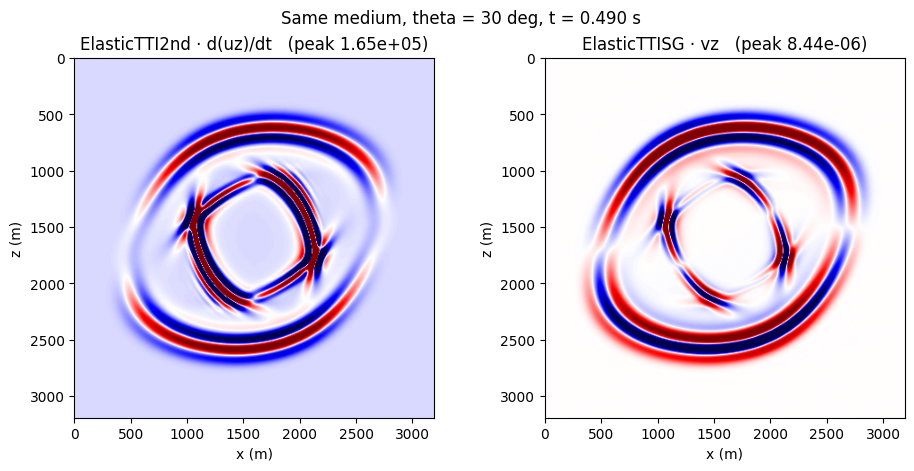

In [8]:
# Each panel gets its OWN colour limits: the two source terms are different
# (a displacement source is not a stress source), so the amplitudes differ by
# orders of magnitude and a shared scale would blank one of them out. What is
# being compared here is where the wavefront sits, not how big it is.
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.6), constrained_layout=True)
for ax, (panel, title) in zip(axes, ((oh_panel, 'ElasticTTI2nd · d(uz)/dt'),
                                     (sg_panel, 'ElasticTTISG · vz'))):
    lo, hi = lim([panel])
    ax.imshow(panel, cmap='seismic', vmin=lo, vmax=hi, aspect='equal', extent=extent)
    ax.set_title(f'{title}   (peak {np.abs(panel).max():.2e})')
    ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
fig.suptitle(f'Same medium, theta = {theta_deg:.0f} deg, t = {T * dt:.3f} s')
plt.show()

## Notes

- **When to reach for this one.** The `vh/η` parametrisation is the point:
  Oh et al. build a multistage FWI on it because `vh` is what a surface
  acquisition constrains first, and it decouples better from η than
  `vp0`/`δ` do from each other. If you want a conventional velocity–stress
  TTI solver, use `ElasticTTISG` (2-D) or `ElasticTTISG3D` (3-D).
- **Gradients.** `impl='c'` implements forward, `full`, boundary saving and
  checkpointing; all six parameters match the eager autograd reference.
- **2-D only, no φ.** The system is P–SV in the x–z plane. For an
  out-of-plane symmetry axis you need the 3-D solver.
- **No free surface**, like every anisotropic equation here.
